In [ ]:
# import subprocess

# try:
#     # print("Updating package lists...")
#     # subprocess.run(["sudo", "apt-get", "update"], check=True, capture_output=True, text=True)
#     print("Installing libxcomposite1, libatk1.0-0, libcairo2, libgdk-pixbuf2.0-0, and libgtk-3-0...")
#     subprocess.run(["sudo", "apt-get", "install", "-y", "libxcomposite1", "libatk1.0-0", "libcairo2", "libgdk-pixbuf2.0-0", "libgtk-3-0"], check=True, capture_output=True, text=True)
#     print("Required libraries installed successfully.")
# except subprocess.CalledProcessError as e:
#     print(f"Error installing libraries: {e.stderr}")
# except Exception as e:
#     print(f"An unexpected error occurred: {e}")

In [1]:
!pip install shot-scraper
!shot-scraper install

In [2]:
# %pip install tiktoken
%pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

import json
import re
import string
import html

In [5]:
from collections import Counter
# import tiktoken
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/fanyak/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## User Input (wikipedia page url)

In [6]:
input_url = input('paste the url of a wikipedia page')

## Scrape Page Content

In [ ]:
############################### Trial for Testing ##############################

# !shot-scraper javascript https://en.wikipedia.org/wiki/MapReduce '(() => { function tableToObjects() {const nodes = Array.from(document.querySelectorAll("section:first-child table, section:first-child p, .mw-heading ~ p, .mw-heading ~ ul, .mw-heading ~ table, ol.references, h1, h2, h3, h4")); const obj = {}; let content = []; let title = ""; const order = []; const tags = []; for (let i = 0; i < nodes.length; i++) { const node = nodes[i]; if (node.id && ["H1", "H2", "H3", "H4"].includes(node.tagName)) {content = [];  title = node.innerText; order.push(title); tags.push(node.tagName?.toLowerCase())} else {content.push(`<${node.tagName.toLowerCase()}>${node.getHTML()}</${node.tagName.toLowerCase()}>`)};  obj[title] = content } return ({obj, order, tags});} return tableToObjects();})'

In [7]:
get_pdf_script = """
(() => { function tableToObjects() {const nodes = Array.from(document.querySelectorAll("section:first-child table, section:first-child p, .mw-heading ~ p, .mw-heading ~ ul, .mw-heading ~ table, ol.references, h1, h2, h3, h4")); const obj = {}; let content = []; let title = ""; const order = []; const tags = []; for (let i = 0; i < nodes.length; i++) { const node = nodes[i]; if (node.id && ["H1", "H2", "H3", "H4"].includes(node.tagName)) {content = [];  title = node.innerText; order.push(title); tags.push(node.tagName?.toLowerCase())} else {content.push(`<${node.tagName.toLowerCase()}>${node.getHTML()}</${node.tagName.toLowerCase()}>`)};  obj[title] = content } return ({obj, order, tags});} return tableToObjects();})
"""
with open('get_pdf.js', 'w') as f:
    f.write(get_pdf_script)

In [99]:
#print(url)

#### scrape the url

In [10]:
url = input_url if input_url else 'https://als.wikipedia.org/wiki/Schweiz'

In [ ]:
!shot-scraper javascript -i get_pdf.js "{url}"

In [12]:
d = !shot-scraper javascript -i get_pdf.js {url}
data = json.loads(d.s)

#### parse the html nodes content

In [15]:
parsed_content = {}
for indx, node in enumerate(data['order']):
  parsed_content[node] = ''
  for paragraph in data['obj'][node]:
    parsed_content[node] += f"{paragraph}"
# parsed_content

In [16]:
page = ''
for indx, node in enumerate(data['order']):
  segment = f"""<{data['tags'][indx].lower()}> {node.replace('_', ' ')}</{data['tags'][indx].lower()}>
  {parsed_content[node]}
  """
  page += segment


#### display the html

In [ ]:
from IPython.display import HTML, display
display(HTML(page))

#### Break down the structure of the page and store it in pandas

In [ ]:
#parsed_content

# Analyze Content
Perform word frequency analysis on the the scraped content of the Wikipedia article. The analysis should include cleaning and normalizing the text, tokenizing words, removing stop words, identifying the top N most frequent words, visualizing these words with a bar chart, and summarizing the insights to highlight the article's main themes.

## Unify all Content

Convert the `parsed_content` dictionary into a single string of plain text by removing HTML tags and other non-text elements. This will prepare the data for text analysis.


In [18]:
def unifyContent(parsed_content):
  combined_text = ""
  for key in parsed_content:
      combined_text += parsed_content[key]
  return combined_text


## Clean and Normalize Text

Preprocess the extracted text by converting it to lowercase, removing punctuation, special characters, numbers, and extra whitespace. This step ensures consistent word forms for accurate counting.


In [19]:
def clean(text):
  # remove all image content and text
  text = re.sub(r'<figure>.*?</figure>', '', text, flags=re.S)
  text = re.sub(r'<img>.*?</img>', '', text, flags=re.S)
  # remove wiki template syntax like {{{ARTIKEL-FLAGGE}}}
  text = re.sub(r'\{\{\{.*?\}\}\}', '', text, flags=re.S)
  # remove html entities (&nbsp; ...)
  text = html.unescape(text)
  #remove html tags
  plain_text = re.sub(r'<[^>]+>', ' ', text)
  # convert to lower case
  normalized_text = plain_text.lower()
  # Remove punctuation
  normalized_text = re.sub(f'[{re.escape(string.punctuation)}]', ' ', normalized_text)
  # Remove numbers
  normalized_text = re.sub(r'\d+', '', normalized_text)
  # remove special characters
  #normalized_text = re.sub('\xad', '', normalized_text)
  # Replace multiple spaces with a single space and remove leading/trailing whitespace
  normalized_text = re.sub(r'\s+', ' ', normalized_text).strip()

  return normalized_text

In [ ]:
def getCleanText(content = parsed_content):
  clean_text = clean(unifyContent(content))
  #find remain characters that are neither words nor spaces
  existing_no_word_chars = set(re.findall(r"[\W]", clean_text))
  if len(existing_no_word_chars) > 0:
    for char in existing_no_word_chars:
      clean_text = re.sub(char.strip(), '', clean_text)
  return clean_text


In [108]:
# existing_no_word_chars

In [21]:
clean_text = getCleanText(parsed_content)

## Tokenize and Count Words


Split the cleaned text into individual words (tokens) and then calculate the frequency of each word. This will give us a raw count of how often each word appears in the Wikipedia article.


In [ ]:
# import nltk
# from nltk.tokenize import word_tokenize
# tokenizer = tiktoken.get_encoding("gpt2")
def getWordCounts(text = clean_text):
  tokens = text.split()
  word_counts = Counter(tokens)
  return word_counts


## Remove Stop Words

Filter out common English (or appropriate language for the article) stop words (e.g., 'the', 'is', 'and') from the word frequency counts, as these often do not carry significant meaning for analysis.


In [111]:
# check available languages for stopwords
#stopwords.fileids()

In [23]:
def getStopwordsForContent(language = 'english'):
  naive_language_to_wiki_match = {
      'als': 'german',
      'el': 'german',
      'en': 'english',
      'es': 'spanish',
      'fr': 'french',
      'it': 'italian',
      'de': 'german',
      'nl': 'dutch',
      'pl': 'polish',
      'pt': 'portuguese',
      'ru': 'russian',
      'sv': 'swedish',
      'tr': 'turkish',
      'zh': 'chinese',
      'zh-tw': 'chinese',
      'zh-cn': 'chinese',
      'zh-sg': 'chinese',
      'hu': 'hungarian',
      'ro': 'romanian',
      'nl-be': 'dutch',
      'nl-nl': 'dutch',
      'da': 'danish',
      'fi': 'finnish',
      'no': 'norwegian',
      'cs': 'czech',
      'sk': 'slovak',
      'sl': 'slovenian',
      'hr': 'croatian',
      'bg': 'bulgarian',
      'albanian': 'albanian',
      'ar': 'arabic',
      'az': 'azerbaijani',
      'be': 'belarusian',
      'bg': 'bulgarian',
      'ca': 'catalan'
  }
  try:
    lang = url.split('//')[-1].split('.')[0]
    stopwords_flag = naive_language_to_wiki_match.get(lang) or language
    stopwords_for_content = set(stopwords.words(stopwords_flag))
  except LookupError:
    stopwords_for_content = set(stopwords.words(language))
  return stopwords_for_content


In [ ]:

def filterContentByStopwords(word_counts, stopwords_for_content):
  filtered_word_counts = Counter()
  for word, count in word_counts.items():
      if word not in stopwords_for_content:
          filtered_word_counts[word] = count
  return filtered_word_counts
filtered_word_counts = filterContentByStopwords(getWordCounts(clean_text), getStopwordsForContent())


## Identify Top N Words


Determine the top N most frequently occurring words after stop word removal. To get top N we use `.most_common()` method on the filtered_word_counts Counter object


In [25]:
N = 20
top_n_words = filtered_word_counts.most_common(N)


**Reasoning**:
To visualize the top N words, I need to create a bar chart. This requires importing `matplotlib.pyplot` for plotting, extracting the words and their counts from `top_n_words`, and then generating the bar chart with appropriate labels and a title.



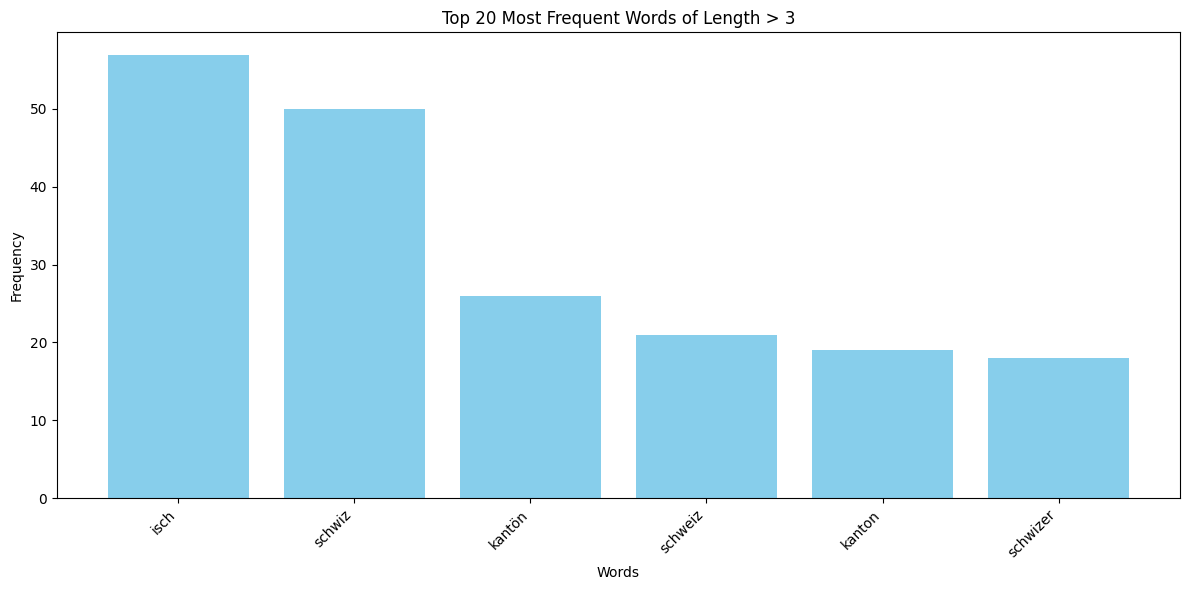

Displayed a bar chart of the top 20 most frequent words.


In [26]:

# Prepare data for plotting
words = [word for word, count in top_n_words if len(word) > 3]
counts = [count for word, count in top_n_words if len(word) > 3]

# Create the bar chart
plt.figure(figsize=(12, 6))
plt.bar(words, counts, color='skyblue')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title(f'Top {N} Most Frequent Words of Length > 3')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Displayed a bar chart of the top {N} most frequent words.")

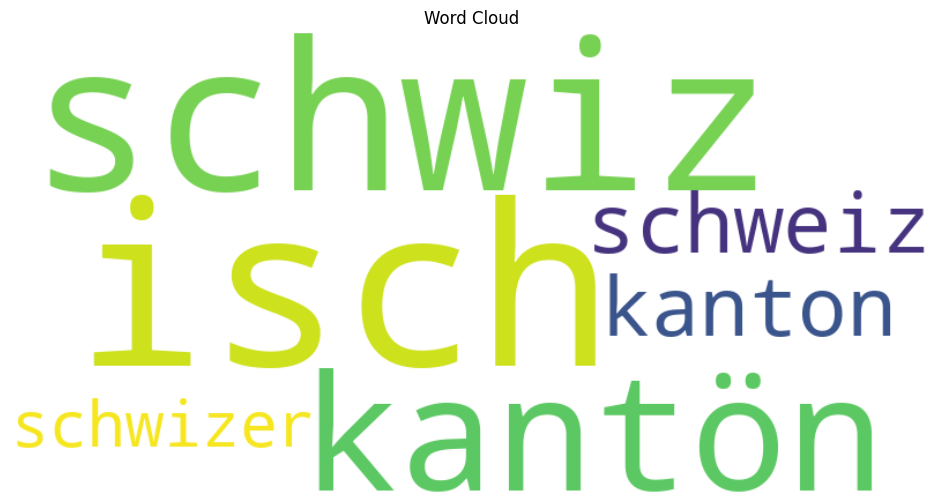

In [27]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(words))

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud")
plt.show()

# Summarize Insights



The analysis of the Wikipedia article on "Schweiz" (Switzerland) reveals several key themes based on the most frequent words after preprocessing and stop word removal. The top 20 words largely revolve around geographical, political, and cultural aspects of Switzerland.

*   **Geographical and Administrative Structure:** Words like `kantön` (cantons), `schwiz` (Switzerland), `em` (likely a form of 'im' meaning 'in' or a pronoun 'them'), `dr` (the), `de` (the), `vo` (of), `uf` (on/upon) indicate a strong focus on the country's unique federal structure and physical landscape.
*   **Identity and Belonging:** The consistent appearance of `schwiz` and `schwizer` (Swiss) directly points to the article's core subject and national identity.
*   **High-Frequency Common Words:** Even after removing German stopwords, some very common words like `d` (the), `isch` (is), `het` (has), `i` (in), `e` (a), `au` (also), `si` (they/are) remain prominent. These are often structural elements of the German language that are difficult to fully filter without potentially losing context.

Overall, the most frequent non-stopwords suggest that the article provides a foundational overview of Switzerland, emphasizing its administrative divisions, geographical characteristics, and national identity. The presence of words like 'kantön' is particularly informative, immediately pointing to the decentralized nature of Swiss governance.